# Laboratorium 7 – Zadania rozpoznawania
**Analiza i przetwarzanie obrazów**  
AGH, Informatyka Stosowana II st., Semestr I

## A) Porównanie metod detekcji punktów charakterystycznych (lab5_2.png)

**Ocena metod:**
- **Harris** – wykrywa narożniki, prosta i szybka, ale nie skalowalna
- **SIFT** – skalo- i rotacyjnie niezmiennicza, dobra jakość, wolniejsza
- **SURF** – podobna do SIFT, szybsza (wymaga opencv-contrib)
- **FAST** – najszybsza, brak opisu deskryptorem, czuła na szum
- **ORB** – dobry kompromis: szybka, z deskryptorem, dobra do zastosowań real-time

SURF niedostępny – wymaga opencv-contrib-python


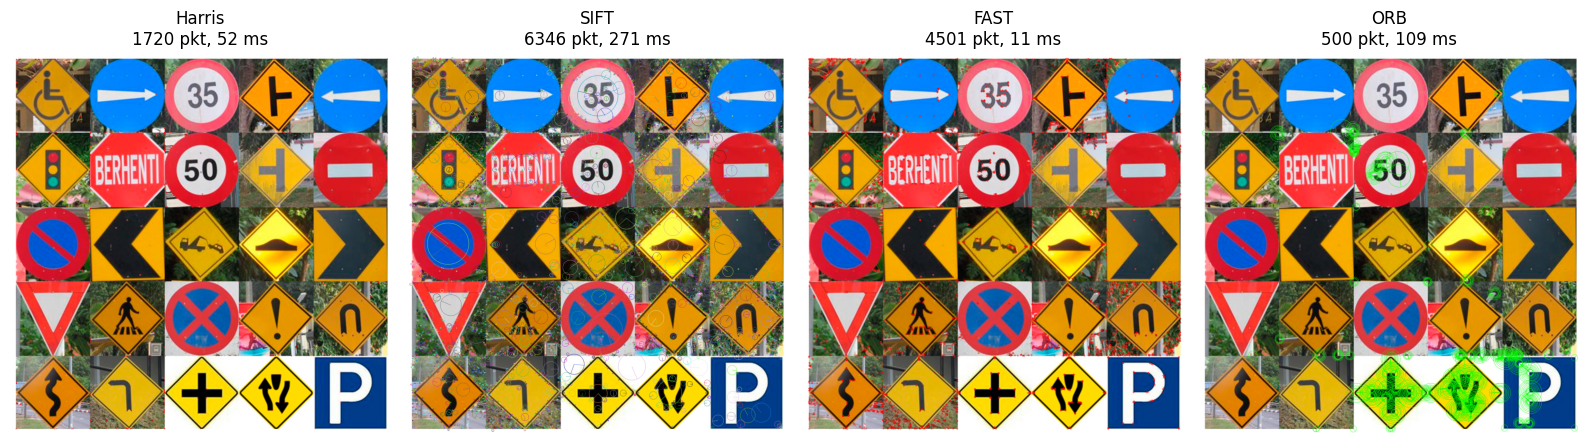

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time

plt.rcParams['figure.figsize'] = [16, 8]

img_bgr = cv2.imread('../images/lab5_2.png')
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

results = {}

# Harris
t0 = time.time()
dst = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)
harris_img = img.copy()
harris_img[cv2.dilate(dst, None) > 0.01 * dst.max()] = [255, 0, 0]
results['Harris'] = (harris_img, time.time()-t0, int((dst > 0.01*dst.max()).sum()))

# SIFT
t0 = time.time()
sift = cv2.SIFT_create()
kp_sift, _ = sift.detectAndCompute(gray, None)
sift_img = cv2.drawKeypoints(img, kp_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
results['SIFT'] = (sift_img, time.time()-t0, len(kp_sift))

# SURF (wymaga opencv-contrib)
try:
    t0 = time.time()
    surf = cv2.xfeatures2d.SURF_create(400)
    kp_surf, _ = surf.detectAndCompute(gray, None)
    surf_img = cv2.drawKeypoints(img, kp_surf, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    results['SURF'] = (surf_img, time.time()-t0, len(kp_surf))
except AttributeError:
    print("SURF niedostępny – wymaga opencv-contrib-python")

# FAST
t0 = time.time()
fast = cv2.FastFeatureDetector_create(threshold=20)
kp_fast = fast.detect(gray, None)
fast_img = cv2.drawKeypoints(img, kp_fast, None, color=(255, 0, 0))
results['FAST'] = (fast_img, time.time()-t0, len(kp_fast))

# ORB
t0 = time.time()
orb = cv2.ORB_create(nfeatures=500)
kp_orb, _ = orb.detectAndCompute(gray, None)
orb_img = cv2.drawKeypoints(img, kp_orb, None, color=(0, 255, 0),
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
results['ORB'] = (orb_img, time.time()-t0, len(kp_orb))

fig, axes = plt.subplots(1, len(results))
for ax, (name, (im, t, n)) in zip(axes, results.items()):
    ax.imshow(im); ax.set_title(f'{name}\n{n} pkt, {t*1000:.0f} ms'); ax.axis('off')
plt.tight_layout()
plt.show()

## B) Wykrywanie twarzy w sekwencji wideo – kaskada Haara

Używamy vid1.mov. W filmie dashcam twarzy może nie być – kod działa poprawnie dla dowolnego wideo zawierającego twarze frontem do kamery.

Przetworzono 481 klatek → ../output/lab7_faces.mp4


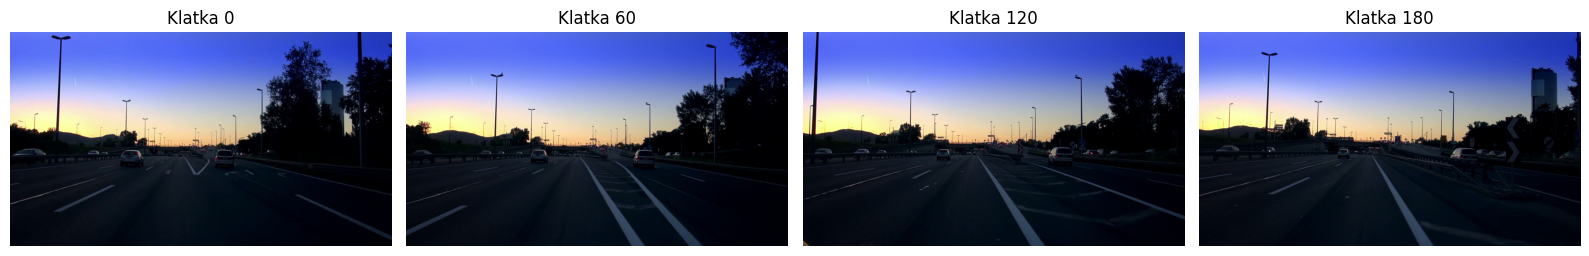

In [2]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

cap = cv2.VideoCapture('../videos/vid1.mov')
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

import os; os.makedirs('images/output', exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('../output/lab7_faces.mp4', fourcc, fps, (width, height))

samples = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray_f = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces  = face_cascade.detectMultiScale(gray_f, 1.1, 4)
    result = frame.copy()
    for (x, y, fw, fh) in faces:
        cv2.rectangle(result, (x, y), (x+fw, y+fh), (0, 255, 0), 2)

    out.write(result)
    if frame_idx % 60 == 0:
        samples.append(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    frame_idx += 1

cap.release()
out.release()
print(f"Przetworzono {frame_idx} klatek → ../output/lab7_faces.mp4")

fig, axes = plt.subplots(1, min(len(samples), 4))
if len(samples) == 1:
    axes = [axes]
for i, (ax, fr) in enumerate(zip(axes, samples[:4])):
    ax.imshow(fr); ax.set_title(f'Klatka {i*60}'); ax.axis('off')
plt.tight_layout()
plt.show()